In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [5]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [7]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [8]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [9]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [10]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.055200,0.961720
2,0.539900,0.928066
3,0.165000,1.337097


Обучение завершено за 324.11 секунд (0:05:24)


In [11]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6676
F1 Micro: 0.6676
F1 Macro: 0.5934
F1 Weighted: 0.6621
MAE: 0.4109
              precision    recall  f1-score   support

           1       0.80      0.76      0.78       153
           2       0.60      0.67      0.63       227
           3       0.64      0.76      0.70       475
           4       0.70      0.61      0.65       343
           5       0.68      0.57      0.62       237
           6       0.75      0.10      0.18        30

    accuracy                           0.67      1465
   macro avg       0.70      0.58      0.59      1465
weighted avg       0.67      0.67      0.66      1465



0.6676
0.6676
0.5934
0.6621
0.4109
324.11


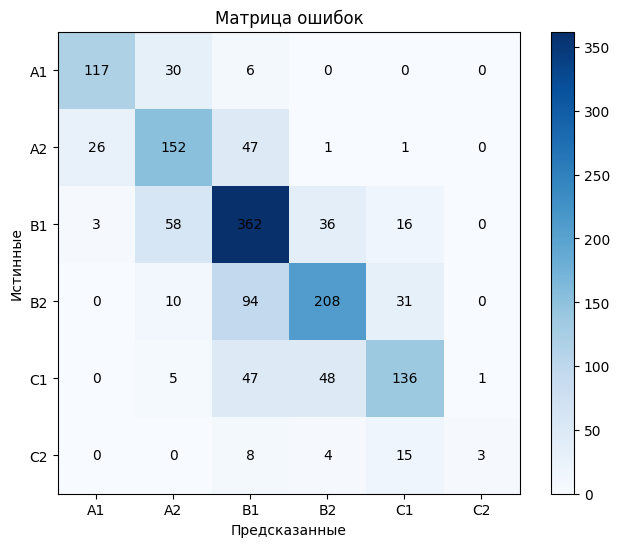

In [12]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [13]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.052900,0.959777
2,0.540900,1.043103
3,0.130500,1.483370


Обучение завершено за 328.78 секунд (0:05:28)


In [14]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5141
F1 Weighted: 0.6140
MAE: 0.4478
              precision    recall  f1-score   support

           1       0.90      0.43      0.58       153
           2       0.53      0.76      0.62       227
           3       0.63      0.71      0.67       475
           4       0.64      0.58      0.61       343
           5       0.63      0.57      0.60       237
           6       0.00      0.00      0.00        30

    accuracy                           0.62      1465
   macro avg       0.56      0.51      0.51      1465
weighted avg       0.63      0.62      0.61      1465



0.6225
0.6225
0.5141
0.6140
0.4478
328.78


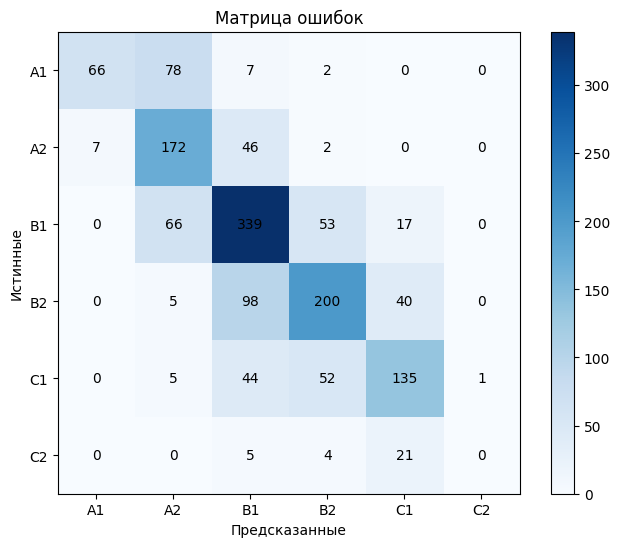

In [15]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [16]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.055700,0.963095
2,0.550500,1.024881
3,0.171100,1.414837


Обучение завершено за 329.17 секунд (0:05:29)


In [17]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6184
F1 Micro: 0.6184
F1 Macro: 0.5225
F1 Weighted: 0.6114
MAE: 0.4526
              precision    recall  f1-score   support

           1       0.94      0.41      0.57       153
           2       0.52      0.77      0.62       227
           3       0.63      0.67      0.65       475
           4       0.62      0.61      0.61       343
           5       0.65      0.59      0.62       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.64      0.51      0.52      1465
weighted avg       0.64      0.62      0.61      1465



0.6184
0.6184
0.5225
0.6114
0.4526
329.17


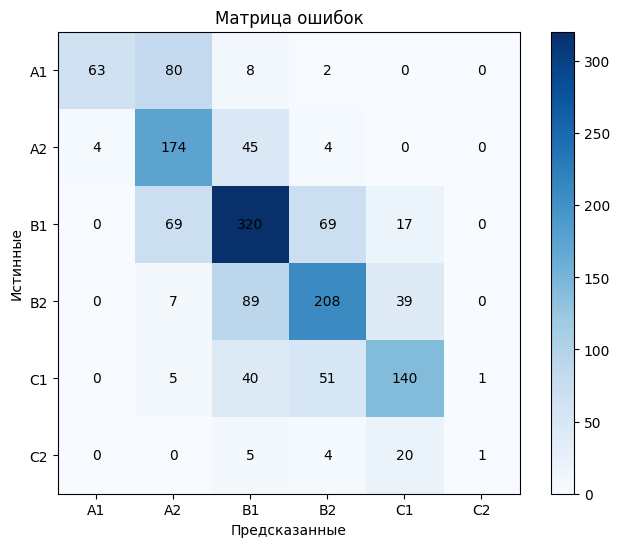

In [18]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [19]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.048000,0.966207
2,0.553300,1.056387
3,0.153200,1.476763


Обучение завершено за 329.20 секунд (0:05:29)


In [20]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6061
F1 Micro: 0.6061
F1 Macro: 0.5177
F1 Weighted: 0.5996
MAE: 0.4703
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.51      0.76      0.61       227
           3       0.60      0.68      0.64       475
           4       0.63      0.53      0.57       343
           5       0.64      0.58      0.61       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.63      0.51      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6061
0.6061
0.5177
0.5996
0.4703
329.20


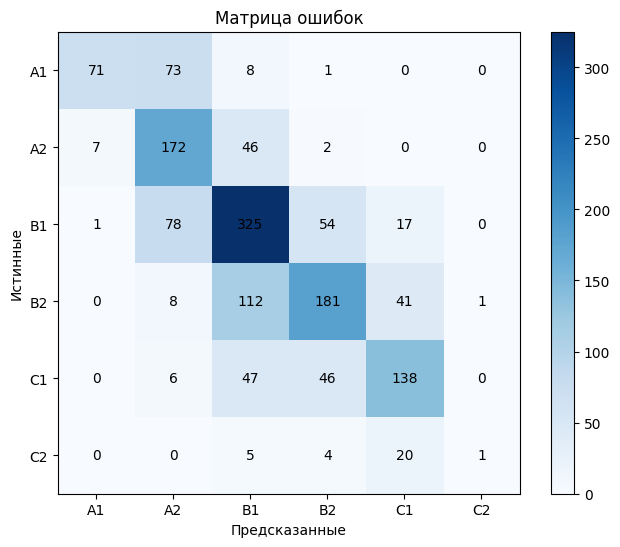

In [21]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [22]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.064200,0.947327
2,0.556400,0.998371
3,0.141000,1.472214


Обучение завершено за 329.32 секунд (0:05:29)


In [23]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6198
F1 Micro: 0.6198
F1 Macro: 0.5286
F1 Weighted: 0.6140
MAE: 0.4519
              precision    recall  f1-score   support

           1       0.91      0.47      0.62       153
           2       0.53      0.74      0.61       227
           3       0.62      0.68      0.65       475
           4       0.63      0.58      0.60       343
           5       0.63      0.61      0.62       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.64      0.52      0.53      1465
weighted avg       0.64      0.62      0.61      1465



0.6198
0.6198
0.5286
0.6140
0.4519
329.32


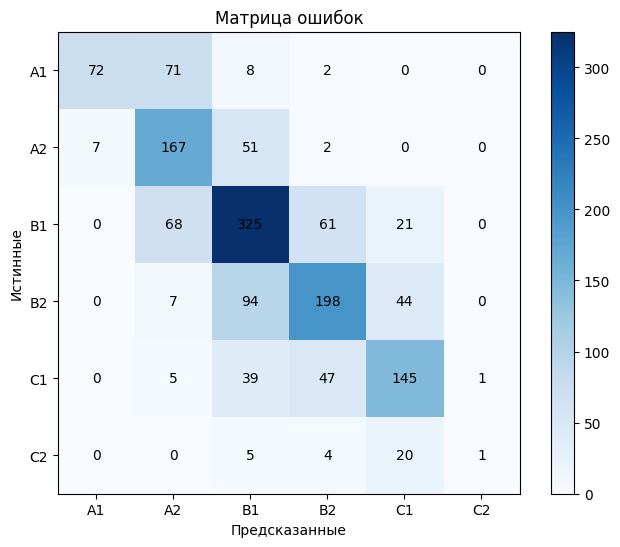

In [24]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [25]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.044200,0.960733
2,0.545400,1.027228
3,0.139700,1.445994


Обучение завершено за 329.17 секунд (0:05:29)


In [26]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6157
F1 Micro: 0.6157
F1 Macro: 0.5118
F1 Weighted: 0.6077
MAE: 0.4573
              precision    recall  f1-score   support

           1       0.92      0.44      0.60       153
           2       0.52      0.75      0.62       227
           3       0.62      0.70      0.66       475
           4       0.63      0.57      0.60       343
           5       0.64      0.57      0.61       237
           6       0.00      0.00      0.00        30

    accuracy                           0.62      1465
   macro avg       0.55      0.51      0.51      1465
weighted avg       0.63      0.62      0.61      1465



0.6157
0.6157
0.5118
0.6077
0.4573
329.17


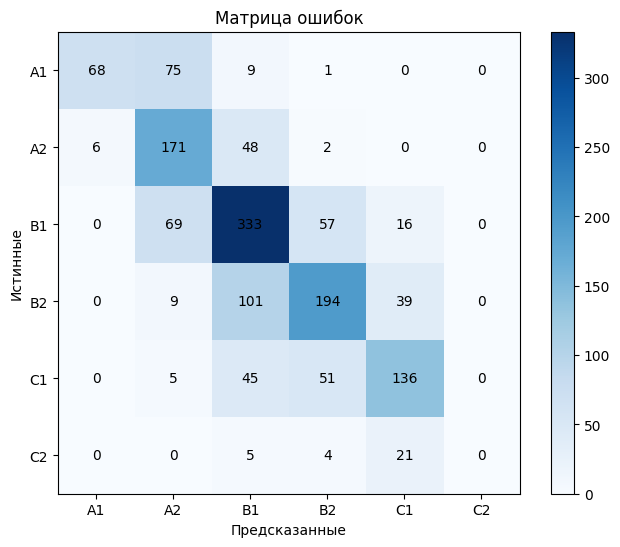

In [27]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [28]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.068200,0.964496
2,0.561600,1.041095
3,0.139700,1.450635


Обучение завершено за 329.45 секунд (0:05:29)


In [29]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6164
F1 Micro: 0.6164
F1 Macro: 0.5127
F1 Weighted: 0.6088
MAE: 0.4567
              precision    recall  f1-score   support

           1       0.90      0.43      0.58       153
           2       0.51      0.78      0.62       227
           3       0.63      0.66      0.65       475
           4       0.62      0.59      0.60       343
           5       0.64      0.60      0.62       237
           6       0.00      0.00      0.00        30

    accuracy                           0.62      1465
   macro avg       0.55      0.51      0.51      1465
weighted avg       0.63      0.62      0.61      1465



0.6164
0.6164
0.5127
0.6088
0.4567
329.45


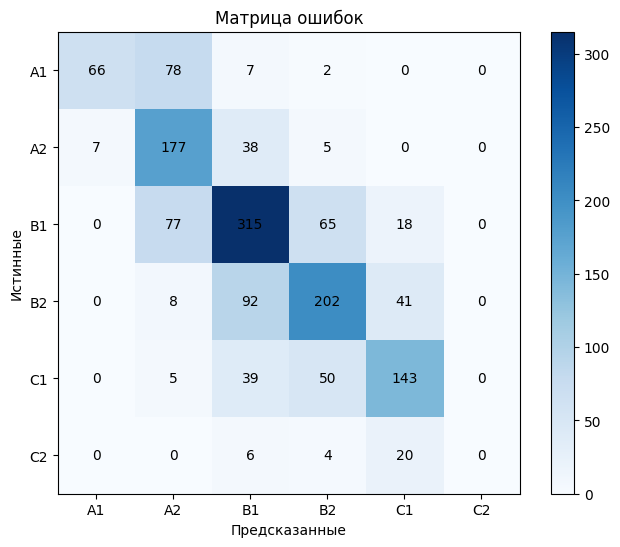

In [30]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [31]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.051300,0.952504
2,0.553300,1.035835
3,0.157500,1.465810


Обучение завершено за 329.59 секунд (0:05:29)


In [32]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6198
F1 Micro: 0.6198
F1 Macro: 0.5297
F1 Weighted: 0.6141
MAE: 0.4498
              precision    recall  f1-score   support

           1       0.93      0.49      0.64       153
           2       0.54      0.73      0.62       227
           3       0.62      0.69      0.66       475
           4       0.60      0.58      0.59       343
           5       0.64      0.58      0.61       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.64      0.52      0.53      1465
weighted avg       0.64      0.62      0.61      1465



0.6198
0.6198
0.5297
0.6141
0.4498
329.59


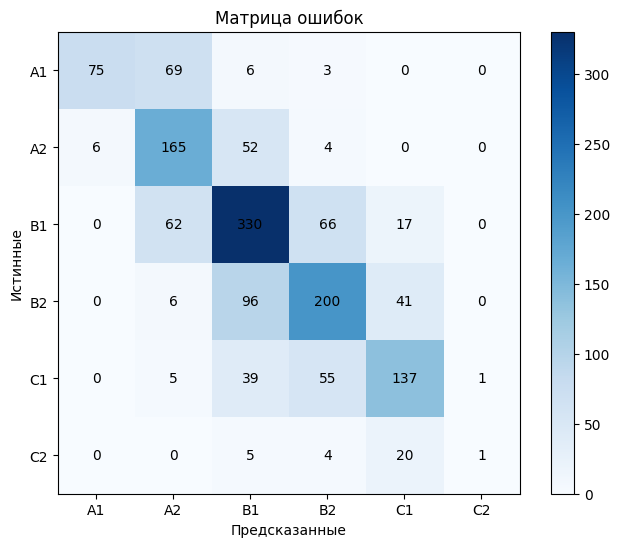

In [33]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [34]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.049000,0.962794
2,0.550600,1.023714
3,0.145900,1.456352


Обучение завершено за 329.68 секунд (0:05:29)


In [35]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6082
F1 Micro: 0.6082
F1 Macro: 0.5150
F1 Weighted: 0.6008
MAE: 0.4655
              precision    recall  f1-score   support

           1       0.90      0.43      0.58       153
           2       0.52      0.74      0.61       227
           3       0.60      0.70      0.65       475
           4       0.61      0.55      0.58       343
           5       0.64      0.57      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.63      0.50      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6082
0.6082
0.5150
0.6008
0.4655
329.68


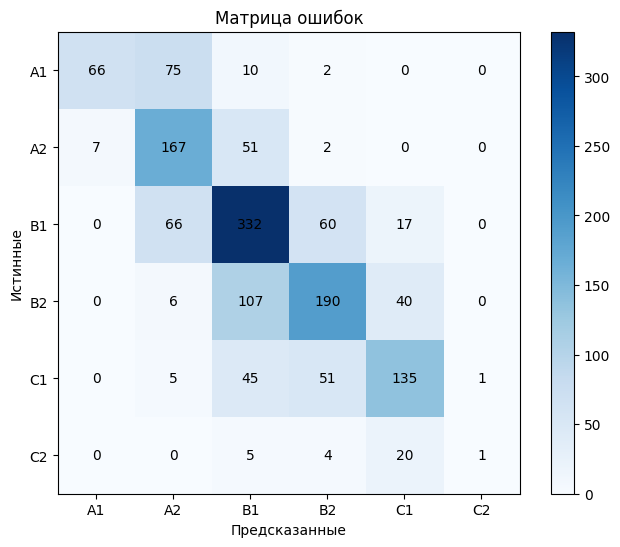

In [36]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [37]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.049300,0.955167
2,0.543000,1.011110
3,0.140000,1.452870


Обучение завершено за 329.49 секунд (0:05:29)


In [38]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6218
F1 Micro: 0.6218
F1 Macro: 0.5376
F1 Weighted: 0.6163
MAE: 0.4498
              precision    recall  f1-score   support

           1       0.91      0.46      0.61       153
           2       0.52      0.74      0.61       227
           3       0.63      0.69      0.66       475
           4       0.64      0.57      0.60       343
           5       0.63      0.61      0.62       237
           6       0.67      0.07      0.12        30

    accuracy                           0.62      1465
   macro avg       0.67      0.52      0.54      1465
weighted avg       0.64      0.62      0.62      1465



0.6218
0.6218
0.5376
0.6163
0.4498
329.49


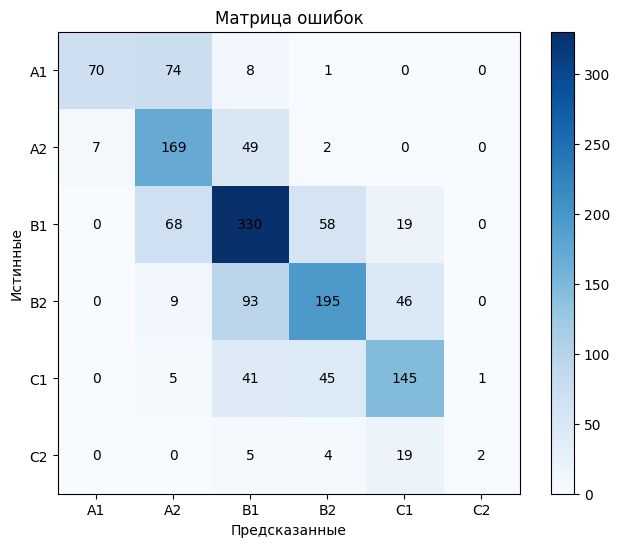

In [39]:
visualize_cm(true_labels, predictions)

# Температура 1.1

In [40]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.055000,0.956036
2,0.546000,1.021260
3,0.150400,1.483517


Обучение завершено за 329.52 секунд (0:05:29)


In [41]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6280
F1 Micro: 0.6280
F1 Macro: 0.5364
F1 Weighted: 0.6215
MAE: 0.4457
              precision    recall  f1-score   support

           1       0.90      0.51      0.65       153
           2       0.54      0.77      0.64       227
           3       0.62      0.71      0.67       475
           4       0.65      0.55      0.59       343
           5       0.64      0.59      0.61       237
           6       0.33      0.03      0.06        30

    accuracy                           0.63      1465
   macro avg       0.61      0.53      0.54      1465
weighted avg       0.64      0.63      0.62      1465



0.6280
0.6280
0.5364
0.6215
0.4457
329.52


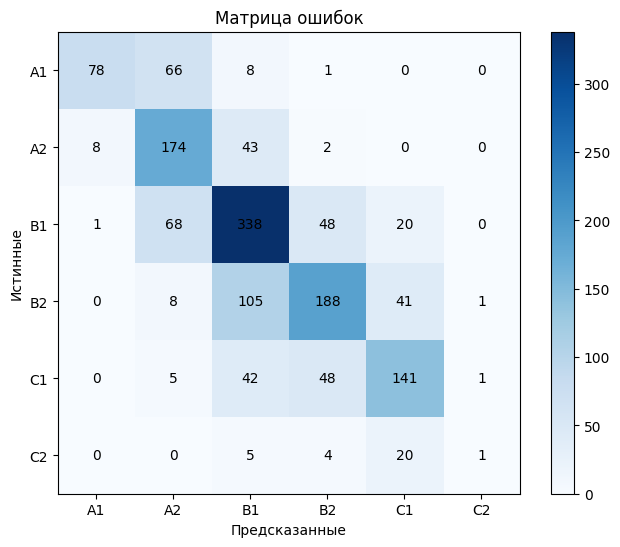

In [42]:
visualize_cm(true_labels, predictions)

# Температура 1.2

In [43]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.050800,0.954390
2,0.547900,1.010437
3,0.145800,1.470644


Обучение завершено за 329.43 секунд (0:05:29)


In [44]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6171
F1 Micro: 0.6171
F1 Macro: 0.5227
F1 Weighted: 0.6101
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.91      0.44      0.59       153
           2       0.52      0.74      0.61       227
           3       0.62      0.70      0.66       475
           4       0.63      0.56      0.59       343
           5       0.64      0.60      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.65      0.62      0.61      1465



0.6171
0.6171
0.5227
0.6101
0.4539
329.43


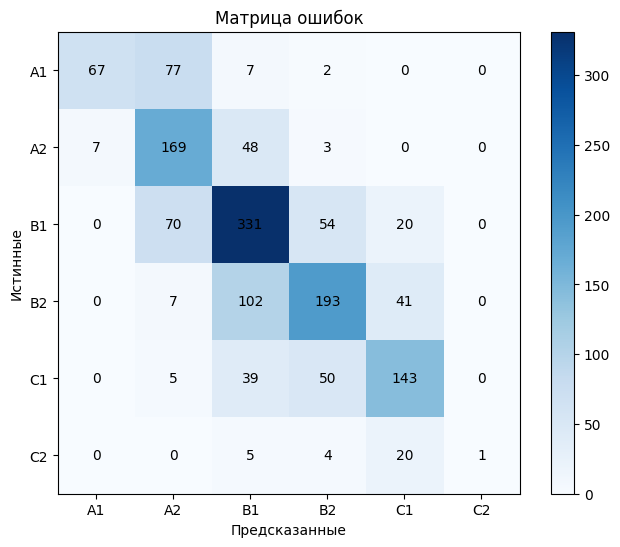

In [45]:
visualize_cm(true_labels, predictions)

# Температура 1.3

In [46]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.052100,0.951289
2,0.553900,0.999007
3,0.142500,1.410468


Обучение завершено за 329.61 секунд (0:05:29)


In [47]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6157
F1 Micro: 0.6157
F1 Macro: 0.5248
F1 Weighted: 0.6098
MAE: 0.4512
              precision    recall  f1-score   support

           1       0.91      0.47      0.62       153
           2       0.53      0.74      0.62       227
           3       0.62      0.68      0.65       475
           4       0.61      0.59      0.60       343
           5       0.64      0.56      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.63      0.51      0.52      1465
weighted avg       0.63      0.62      0.61      1465



0.6157
0.6157
0.5248
0.6098
0.4512
329.61


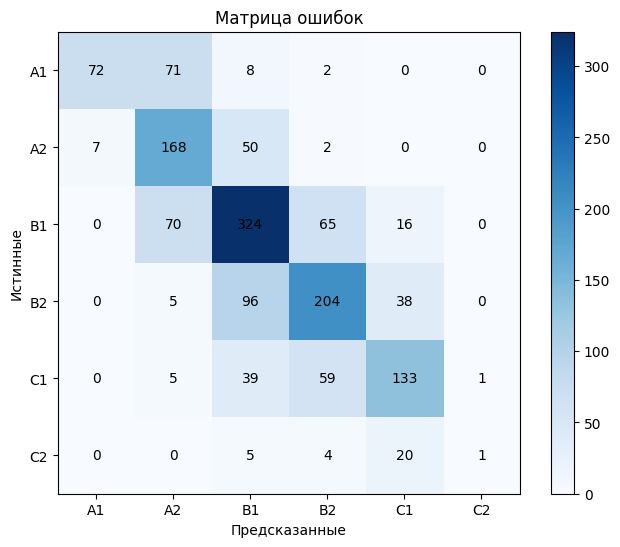

In [48]:
visualize_cm(true_labels, predictions)

# Температура 1.4

In [49]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.045800,0.961404
2,0.552800,0.999247
3,0.145200,1.446712


Обучение завершено за 329.08 секунд (0:05:29)


In [50]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6157
F1 Micro: 0.6157
F1 Macro: 0.5239
F1 Weighted: 0.6090
MAE: 0.4608
              precision    recall  f1-score   support

           1       0.91      0.46      0.61       153
           2       0.52      0.74      0.61       227
           3       0.61      0.70      0.65       475
           4       0.63      0.57      0.60       343
           5       0.65      0.56      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.65      0.62      0.61      1465



0.6157
0.6157
0.5239
0.6090
0.4608
329.08


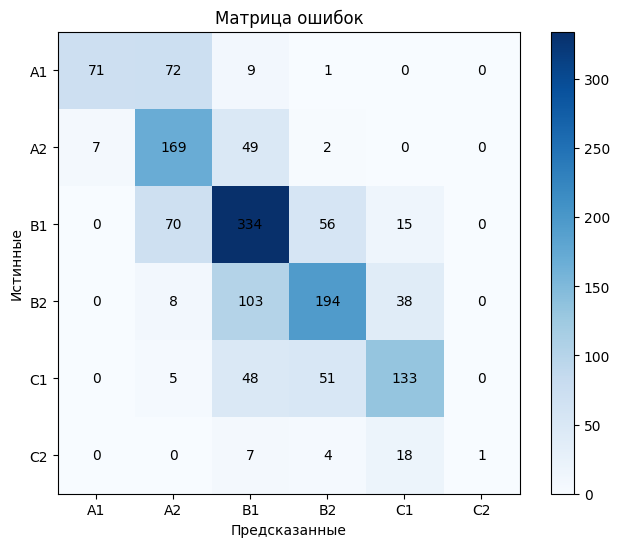

In [51]:
visualize_cm(true_labels, predictions)

# Температура 1.5

In [52]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3_temp_1_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.045100,0.959000
2,0.536800,1.032542
3,0.142700,1.520716


Обучение завершено за 328.76 секунд (0:05:28)


In [53]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5342
F1 Weighted: 0.6169
MAE: 0.4457
              precision    recall  f1-score   support

           1       0.91      0.50      0.65       153
           2       0.54      0.75      0.62       227
           3       0.62      0.68      0.65       475
           4       0.61      0.59      0.60       343
           5       0.66      0.58      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.62      1465



0.6225
0.6225
0.5342
0.6169
0.4457
328.76


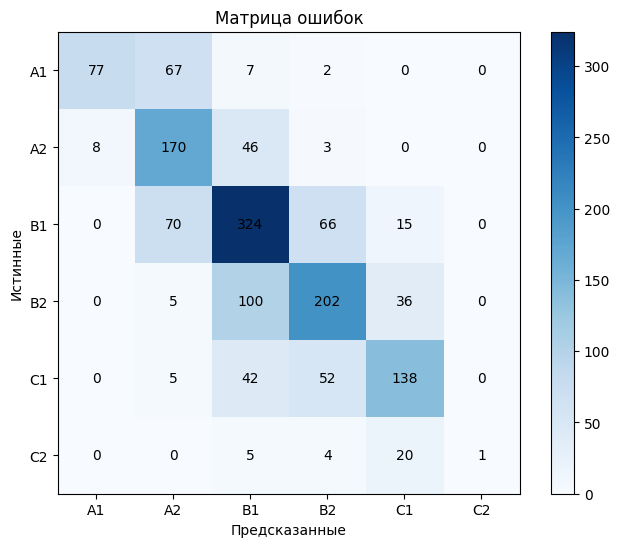

In [54]:
visualize_cm(true_labels, predictions)